# SIRS Autonomous Model with Time-Dependent Parameters

This notebook explores the dynamics of a SIRS model with time-dependent infection and immunity waning rates:

- $\beta(t)$ models seasonal or serotype-driven infection rate
- $\alpha(t)$ models waning immunity dynamics

We simulate different epidemiological scenarios and analyze:
- Infection waves
- Endemic behavior
- Effective reproduction number $R_t$

The model is motivated by dengue dynamics with alternating serotype dominance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Base parameters
rho_0 = 0.01
B_0 = 0.05

rho = np.array([0.05, 0.15, 0.10])
T = np.array([30.5, 82.5, 144.5])

B = np.array([0.4, 0.4, 0.35])
tau = np.array([12, 64, 123])

sigma = np.array([3.2, 3.2, 2.0])
sk = np.array([0.25, 0.25, 0.15])

gamma = 0.15
iota = 3

In [3]:
def alpha(t):
    result = 0
    for i in range(len(rho)):
        result += rho[i] * ((1 + np.tanh(t - (T[i] - iota/2)))/2) * ((1 - np.tanh(t - (T[i] + iota/2)))/2)
    return rho_0 + result


def beta(t):
    result = 0
    for i in range(len(B)):
        result += B[i] * np.exp(-0.5 * ((t - tau[i]) / (sigma[i] + sk[i] * (t - tau[i])))**2)
    return B_0 + result


def Rt(t):
    return beta(t) / gamma

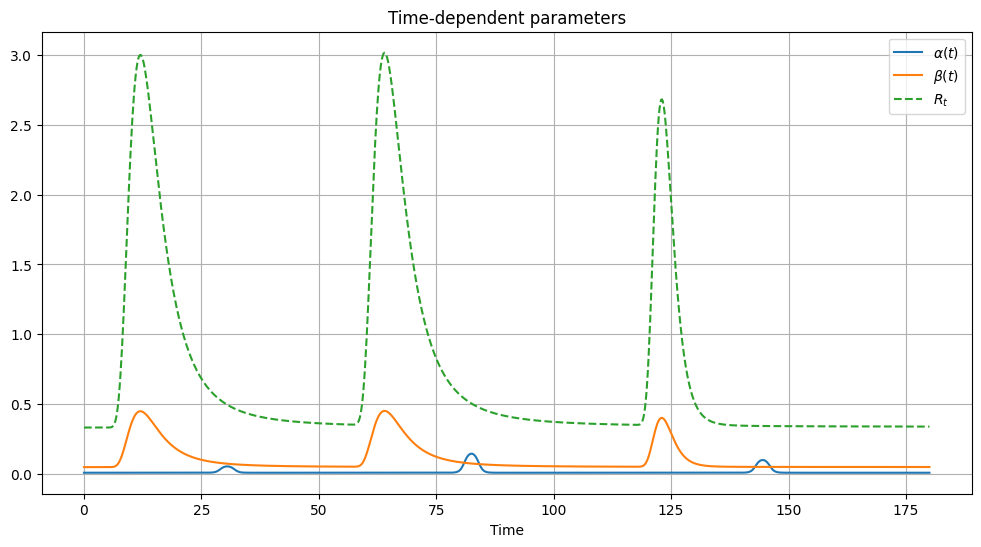

In [4]:
t = np.linspace(0, 180, 1000)

plt.figure(figsize=(12, 6))
plt.plot(t, alpha(t), label=r'$\alpha(t)$')
plt.plot(t, beta(t), label=r'$\beta(t)$')
plt.plot(t, Rt(t), label=r'$R_t$', linestyle='--')
plt.legend()
plt.title("Time-dependent parameters")
plt.xlabel("Time")
plt.grid()
plt.show()

In [5]:
def sirs_model(t, y):
    S, I, R = y
    
    dSdt = -beta(t) * S * I + alpha(t) * R
    dIdt = beta(t) * S * I - gamma * I
    dRdt = gamma * I - alpha(t) * R
    
    return [dSdt, dIdt, dRdt]

In [6]:
# Initial conditions
S0 = 0.99
I0 = 0.01
R0 = 0.0

y0 = [S0, I0, R0]

t_span = (0, 180)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(sirs_model, t_span, y0, t_eval=t_eval)

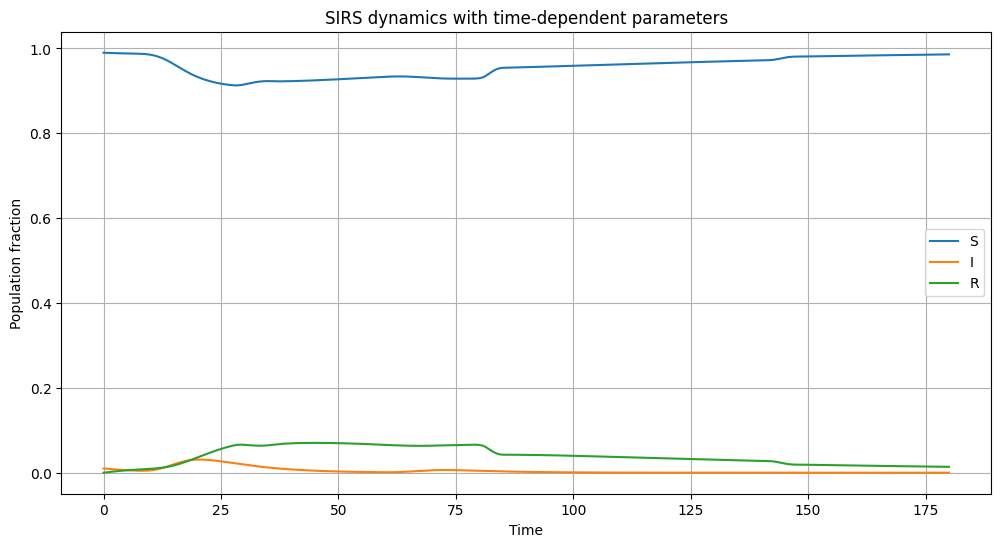

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[0], label='S')
plt.plot(sol.t, sol.y[1], label='I')
plt.plot(sol.t, sol.y[2], label='R')

plt.title("SIRS dynamics with time-dependent parameters")
plt.xlabel("Time")
plt.ylabel("Population fraction")
plt.legend()
plt.grid()
plt.show()

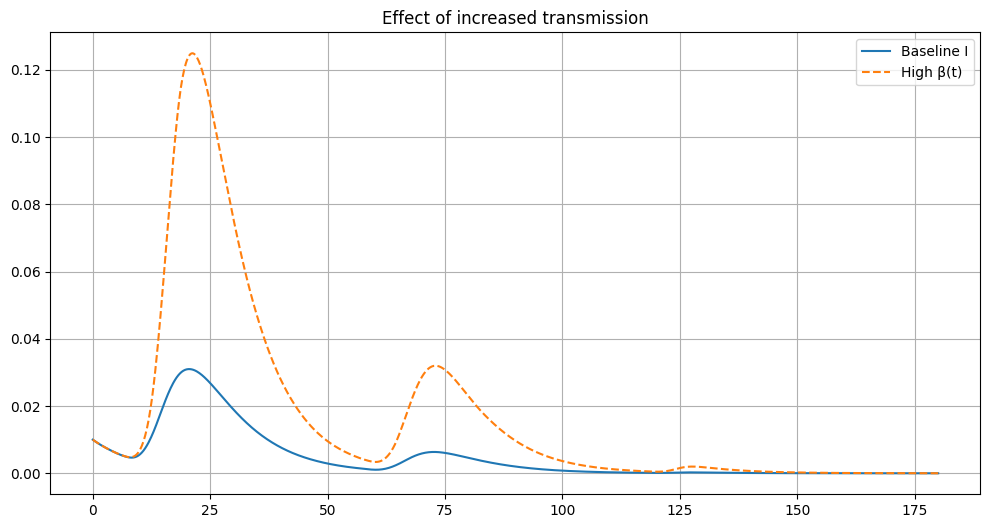

In [8]:
B_high = B * 1.5

def beta_high(t):
    result = 0
    for i in range(len(B_high)):
        result += B_high[i] * np.exp(-0.5 * ((t - tau[i]) / (sigma[i] + sk[i] * (t - tau[i])))**2)
    return B_0 + result


def sirs_high(t, y):
    S, I, R = y
    return [
        -beta_high(t) * S * I + alpha(t) * R,
        beta_high(t) * S * I - gamma * I,
        gamma * I - alpha(t) * R
    ]

sol_high = solve_ivp(sirs_high, t_span, y0, t_eval=t_eval)

plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[1], label="Baseline I")
plt.plot(sol_high.t, sol_high.y[1], label="High β(t)", linestyle='--')
plt.legend()
plt.title("Effect of increased transmission")
plt.grid()
plt.show()

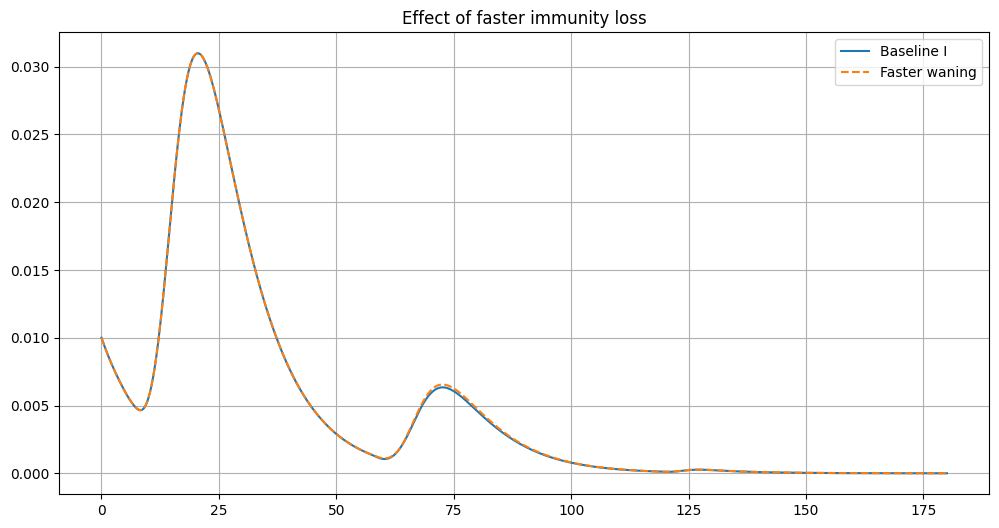

In [9]:
rho_fast = rho * 1.5

def alpha_fast(t):
    result = 0
    for i in range(len(rho_fast)):
        result += rho_fast[i] * ((1 + np.tanh(t - (T[i] - iota/2)))/2) * ((1 - np.tanh(t - (T[i] + iota/2)))/2)
    return rho_0 + result


def sirs_fast(t, y):
    S, I, R = y
    return [
        -beta(t) * S * I + alpha_fast(t) * R,
        beta(t) * S * I - gamma * I,
        gamma * I - alpha_fast(t) * R
    ]

sol_fast = solve_ivp(sirs_fast, t_span, y0, t_eval=t_eval)

plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[1], label="Baseline I")
plt.plot(sol_fast.t, sol_fast.y[1], label="Faster waning", linestyle='--')
plt.legend()
plt.title("Effect of faster immunity loss")
plt.grid()
plt.show()

## Interpretation

- Peaks in $I(t)$ align with peaks in $\beta(t)$, reflecting increased transmission.
- $\alpha(t)$ controls the replenishment of susceptibles, enabling recurrent outbreaks.
- The interplay between $\beta(t)$ and $\alpha(t)$ generates complex endemic oscillations.

This behavior mimics dengue dynamics with alternating serotype dominance.